In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import os


In [96]:
cpi = pd.read_csv("Cost of Living Analysis.py/UK Cost Of Living Project/Data/Raw/Consumer price inflation tables/clean_cpi.csv")
annual_earnings = pd.read_csv("Cost of Living Analysis.py/UK Cost Of Living Project/Data/Raw/Consumer price inflation tables/weekly_earnings.csv")
annual_rent = pd.read_csv("annual_rent_2015_2025.csv")

In [97]:
analysis = cpi.copy()

In [98]:
analysis

,Year,CPIH,Inflation,Cumulative_change
0,2015,100.0,NaN,0.0
1,2016,101.0,1.00,1.0
2,2017,103.6,2.57,3.6
3,2018,106.0,2.32,6.0
4,2019,107.8,1.70,7.8
5,2020,108.9,1.02,8.9
6,2021,111.6,2.48,11.6
7,2022,120.5,7.97,20.5
8,2023,128.6,6.72,28.6
9,2024,132.9,3.34,32.9


In [99]:
annual_earnings = annual_earnings.drop(columns=["CPIH", "Inflation", "Cumulative_change"], errors="ignore")

In [100]:
annual_earnings = annual_earnings.drop(
    columns=["Rent_Index_2015", "Rent_Change"],
    errors="ignore"
)

In [101]:
analysis = cpi.merge(annual_earnings, on="Year", how="left")

analysis = analysis.merge(
    annual_rent[["Year", "Rent_Index_2015", "Rent_Change"]],
    on="Year",
    how="left")

In [102]:
analysis = analysis.merge(
    annual_rent[[
        "Year",
        "Rent_Index_2015",
        "Rent_Change"
    ]],
    on = "Year",
    how="left"
)



In [103]:
analysis = analysis.drop(columns=["Rent_Index_2015_y", "Rent_Change_y"])

analysis = analysis.rename(columns={
    "Rent_Index_2015_x": "Rent_Index_2015",
    "Rent_Change_x": "Rent_Change"
})


In [104]:
analysis

,Year,CPIH,Inflation,Cumulative_change,Weekly_Earnings,Earnings_Growth,Earnings_Index,Real_Earnings_Index,Rent_Index_2015,Rent_Change
0,2015,100.0,NaN,0.0,481.978633,NaN,100.000000,100.000000,100.000000,0.000000
1,2016,101.0,1.00,1.0,493.530641,2.396788,102.396788,101.382959,103.325638,3.325638
2,2017,103.6,2.57,3.6,505.076855,2.339513,104.792375,101.150941,105.846866,5.846866
3,2018,106.0,2.32,6.0,519.836100,2.922178,107.854594,101.749617,106.835387,6.835387
4,2019,107.8,1.70,7.8,537.634198,3.423790,111.547310,103.476169,108.843490,8.843490
5,2020,108.9,1.02,8.9,547.302965,1.798391,113.553367,104.273064,110.770332,10.770332
6,2021,111.6,2.48,11.6,579.912001,5.958133,120.319027,107.812748,112.315157,12.315157
7,2022,120.5,7.97,20.5,615.662578,6.164828,127.736488,106.005384,117.131110,17.131110
8,2023,128.6,6.72,28.6,659.064523,7.049632,136.741440,106.330824,125.794615,25.794615
9,2024,132.9,3.34,32.9,694.165000,5.325803,144.024019,108.370218,136.753945,36.753945


<function matplotlib.pyplot.show(close=None, block=None)>

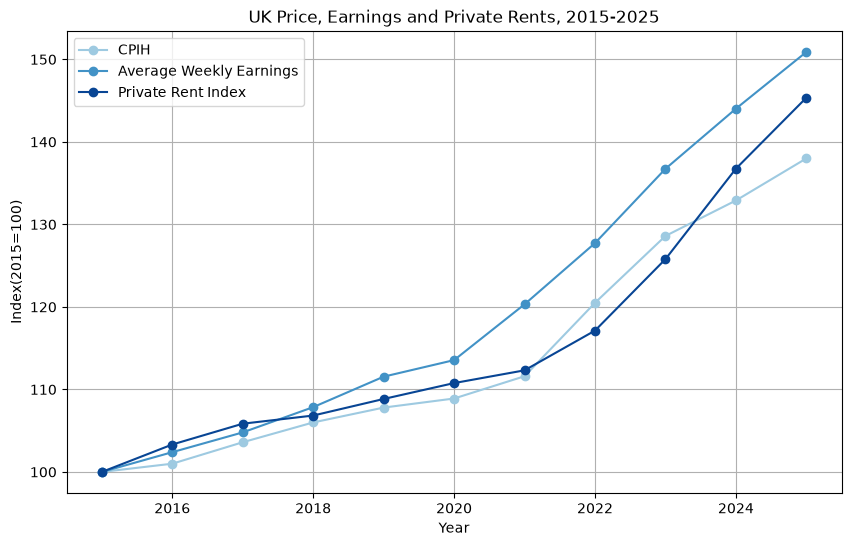

In [105]:
plt.figure(figsize=(10,6))

light_blue = "#9ecae1"
mid_blue   = "#4292c6"
dark_navy  = "#084594"

plt.plot(
    analysis["Year"],
    analysis["CPIH"],
    marker="o",
    color=light_blue,
    label="CPIH"
)
plt.plot(
    analysis["Year"],
    analysis["Earnings_Index"],
    marker="o",
    color=mid_blue,
    label = "Average Weekly Earnings"
)
plt.plot(
    analysis["Year"],
    analysis["Rent_Index_2015"],
    marker = "o",
    color=dark_navy,
    label = "Private Rent Index"
)

plt.xlabel("Year")
plt.ylabel("Index(2015=100)")
plt.title("UK Price, Earnings and Private Rents, 2015-2025")

plt.legend()
plt.grid(True)
plt.show 

In [106]:
analysis["Earnings_minus_Rent"] = (
    analysis["Earnings_Index"] - 
    analysis["Rent_Index_2015"]
)


In [107]:
analysis[[
    "Year",
    "Earnings_Index",
    "Rent_Index_2015",
    "Earnings_minus_Rent"
]]

,Year,Earnings_Index,Rent_Index_2015,Earnings_minus_Rent
0,2015,100.000000,100.000000,0.000000
1,2016,102.396788,103.325638,-0.928850
2,2017,104.792375,105.846866,-1.054492
3,2018,107.854594,106.835387,1.019207
4,2019,111.547310,108.843490,2.703820
5,2020,113.553367,110.770332,2.783035
6,2021,120.319027,112.315157,8.003870
7,2022,127.736488,117.131110,10.605377
8,2023,136.741440,125.794615,10.946825
9,2024,144.024019,136.753945,7.270074


In [108]:
rent_change = analysis.loc[
    analysis["Year"] ==2025,
    "Rent_Change"
].iloc[0]

earnings_change = analysis.loc[
    analysis["Year"] == 2025,
    "Earnings_Index"
].iloc[0] -100

cpi_change = analysis.loc[
    analysis["Year"] ==2025,
    "CPIH"
].iloc[0]-100

print("CPIH change", round(cpi_change,2), "%")
print("Earnings change", round(earnings_change, 2), "%")
print("Private rent change:", round(rent_change,2),"%")

CPIH change 38.0 %
Earnings change 50.9 %
Private rent change: 45.36 %


In [109]:
analysis.to_csv(
    "UK_cost_of_living_analysis_2015_2025.csv",
    index=False
)

In [110]:
annual_rent

,Year,Rent_Index,Rent_Index_2015,Rent_Change
0,2015,82.576364,100.000000,0.000000
1,2016,85.322556,103.325638,3.325638
2,2017,87.404494,105.846866,5.846866
3,2018,88.220779,106.835387,6.835387
4,2019,89.878997,108.843490,8.843490
5,2020,91.470113,110.770332,10.770332
6,2021,92.745773,112.315157,12.315157
7,2022,96.722613,117.131110,17.131110
8,2023,103.876620,125.794615,25.794615
9,2024,112.926436,136.753945,36.753945


In [129]:
analysis["Earnings_minus_Inflation"] = (
    analysis["Earnings_Growth"] - 
    analysis["Inflation"]
)

In [113]:
analysis[[
    "Year",
    "Inflation",
    "Earnings_Growth",
    "Earnings_minus_Inflation"
]]

,Year,Inflation,Earnings_Growth,Earnings_minus_Inflation
0,2015,NaN,NaN,NaN
1,2016,1.00,2.396788,1.396788
2,2017,2.57,2.339513,-0.230487
3,2018,2.32,2.922178,0.602178
4,2019,1.70,3.423790,1.723790
5,2020,1.02,1.798391,0.778391
6,2021,2.48,5.958133,3.478133
7,2022,7.97,6.164828,-1.805172
8,2023,6.72,7.049632,0.329632
9,2024,3.34,5.325803,1.985803


In [114]:
analysis[
    analysis["Earnings_minus_Inflation"] < 0
][[
    "Year",
    "Inflation",
    "Earnings_Growth",
    "Earnings_minus_Inflation"
]]

,Year,Inflation,Earnings_Growth,Earnings_minus_Inflation
2,2017,2.57,2.339513,-0.230487
7,2022,7.97,6.164828,-1.805172


In [115]:
analysis.columns

Index(['Year', 'CPIH', 'Inflation', 'Cumulative_change', 'Weekly_Earnings',
       'Earnings_Growth', 'Earnings_Index', 'Real_Earnings_Index',
       'Rent_Index_2015', 'Rent_Change', 'Earnings_minus_Rent',
       'Earnings_minus_Inflation'],
      dtype='str')

In [116]:
headline = pd.DataFrame({
    "Measure": [
        "CPIH",
        "Average Weekly Earnings",
        "Private Rents"
    ],
    "2015_Index": [
        100,
        100,
        100
    ],
    "2025_Index": [
        analysis.loc[
            analysis["Year"] == 2025,
            "CPIH"
        ].iloc[0],
        analysis.loc[
            analysis["Year"] == 2025,
            "Earnings_Index"
        ].iloc[0],
        analysis.loc[
            analysis["Year"] == 2025,
            "Rent_Index_2015"
        ].iloc[0]
    ]
})

headline["Change_2015_2025"] = (
    headline["2025_Index"] /
    headline["2015_Index"] - 1
) * 100

headline

,Measure,2015_Index,2025_Index,Change_2015_2025
0,CPIH,100,138.000000,38.000000
1,Average Weekly Earnings,100,150.900134,50.900134
2,Private Rents,100,145.360073,45.360073


In [117]:
analysis[
    analysis["Earnings_minus_Inflation"] < 0
][[
    "Year",
    "Inflation",
    "Earnings_Growth",
    "Earnings_minus_Inflation"
]]

,Year,Inflation,Earnings_Growth,Earnings_minus_Inflation
2,2017,2.57,2.339513,-0.230487
7,2022,7.97,6.164828,-1.805172


In [118]:
print(annual_earnings.columns.tolist())

['Year', 'Weekly_Earnings', 'Earnings_Growth', 'Earnings_Index', 'Real_Earnings_Index']


In [119]:
analysis["Real_Earnings_Index"] = (
    analysis["Earnings_Index"]/
    analysis["CPIH"]
    *100
)

In [120]:
analysis.loc[
    analysis["Real_Earnings_Index"].idxmin(),
    [
        "Year",
        "Real_Earnings_Index",
        "Inflation",
        "Earnings_Growth"
    ]
]

Year                   2015.0
Real_Earnings_Index     100.0
Inflation                 NaN
Earnings_Growth           NaN
Name: 0, dtype: float64

In [121]:
analysis.loc[
    analysis["Real_Earnings_Index"].idxmax(),
    [
        "Year",
        "Real_Earnings_Index",
        "Inflation",
        "Earnings_Growth"
    ]
]

Year                   2025.000000
Real_Earnings_Index     109.347923
Inflation                 3.840000
Earnings_Growth           4.774283
Name: 10, dtype: float64

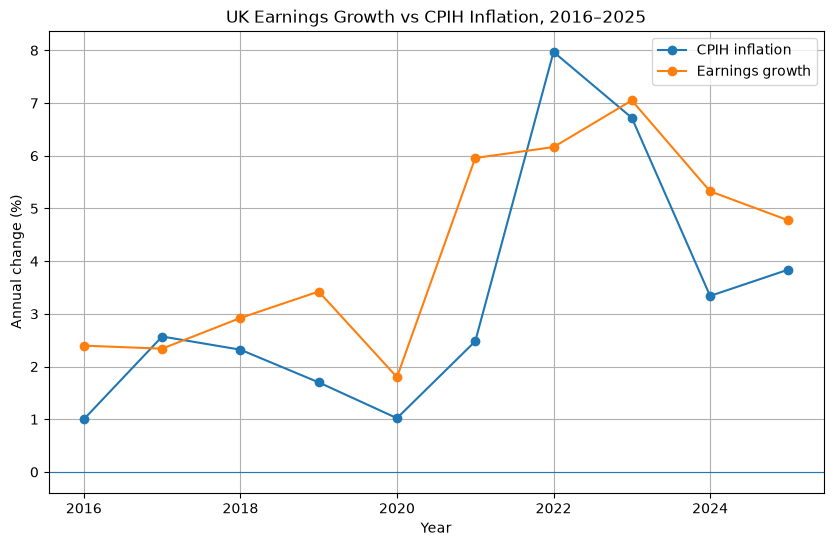

In [122]:
plt.figure(figsize=(10, 6))

plt.plot(
    analysis["Year"],
    analysis["Inflation"],
    marker="o",
    label="CPIH inflation"
)

plt.plot(
    analysis["Year"],
    analysis["Earnings_Growth"],
    marker="o",
    label="Earnings growth"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel("Year")
plt.ylabel("Annual change (%)")
plt.title("UK Earnings Growth vs CPIH Inflation, 2016–2025")

plt.legend()
plt.grid(True)

plt.show()

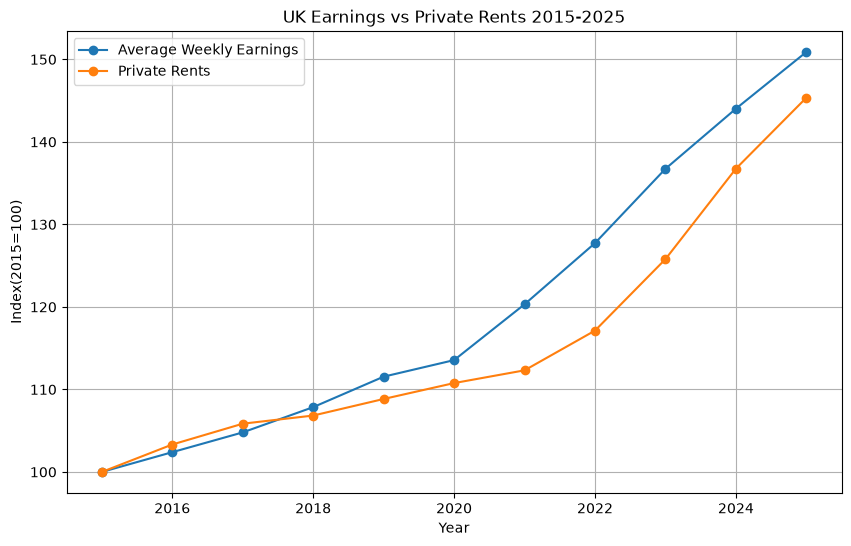

In [123]:
plt.figure(figsize=(10,6))

plt.plot(
    analysis["Year"],
    analysis["Earnings_Index"],
    marker="o",
    label="Average Weekly Earnings"
)
plt.plot(
    analysis["Year"],
    analysis["Rent_Index_2015"],
    marker="o", 
    label="Private Rents"
)

plt.xlabel("Year"),
plt.ylabel("Index(2015=100)")
plt.title("UK Earnings vs Private Rents 2015-2025")

plt.legend()
plt.grid(True)
plt.show()

In [124]:
final_analysis = analysis[[
    "Year",
    "CPIH",
    "Inflation",
    "Cumulative_change",
    "Weekly_Earnings",
    "Earnings_Growth",
    "Earnings_Index",
    "Real_Earnings_Index",
    "Rent_Index_2015",
    "Rent_Change",
    "Earnings_minus_Inflation"
]].copy()

In [125]:
final_analysis

,Year,CPIH,Inflation,Cumulative_change,Weekly_Earnings,Earnings_Growth,Earnings_Index,Real_Earnings_Index,Rent_Index_2015,Rent_Change,Earnings_minus_Inflation
0,2015,100.0,NaN,0.0,481.978633,NaN,100.000000,100.000000,100.000000,0.000000,NaN
1,2016,101.0,1.00,1.0,493.530641,2.396788,102.396788,101.382959,103.325638,3.325638,1.396788
2,2017,103.6,2.57,3.6,505.076855,2.339513,104.792375,101.150941,105.846866,5.846866,-0.230487
3,2018,106.0,2.32,6.0,519.836100,2.922178,107.854594,101.749617,106.835387,6.835387,0.602178
4,2019,107.8,1.70,7.8,537.634198,3.423790,111.547310,103.476169,108.843490,8.843490,1.723790
5,2020,108.9,1.02,8.9,547.302965,1.798391,113.553367,104.273064,110.770332,10.770332,0.778391
6,2021,111.6,2.48,11.6,579.912001,5.958133,120.319027,107.812748,112.315157,12.315157,3.478133
7,2022,120.5,7.97,20.5,615.662578,6.164828,127.736488,106.005384,117.131110,17.131110,-1.805172
8,2023,128.6,6.72,28.6,659.064523,7.049632,136.741440,106.330824,125.794615,25.794615,0.329632
9,2024,132.9,3.34,32.9,694.165000,5.325803,144.024019,108.370218,136.753945,36.753945,1.985803


In [126]:
final_analysis.to_csv(
    "final_cost_of_living_analysis.csv",
    index=False
)


In [127]:
import os
print("final_cost_of_living_analysis.csv")

final_cost_of_living_analysis.csv


In [128]:
final_analysis.to_excel(
    "final_cost_of_living_analysis.xlsx",
    index=False
)